In [ ]:
import pandas as pd

from main import *

logger = CustomLogger(name="jas_test", log_file_name='jas_test.log').get_logger()


In [ ]:
write_predictions = False

l_min = 4
max_diff = 3
c_thresh = 0.9

df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)
logger.info(f"Csv file has bean labeled successfully")

ds = Data_selector(df)
df_modified = ds.select_peaks(goodness=3)
logger.info(f"Rows have been selected successfully")

X, y = select_features_and_get_X_and_y(df_modified)
logger.info(f"Some features have been dropped successfully")

model = Neural_network(input_dim=X.shape[1], epochs=5, verbose=1)
model.scale_and_split_data(X, y)
model.fit()
logger.info(f"Model has been trained successfully")

test_model(model)

if write_predictions:
    write_result(df, model, X)

In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

data = np.array([i for i in range(10)], dtype=float)

X = np.array([[data[i], data[i + 1], data[i + 2]] for i in range(len(data) - 3)])
y = np.array([data[i + 3] for i in range(len(data) - 3)])
X = X.reshape((X.shape[0], X.shape[1], 1))



In [2]:
model = Sequential()
model.add(SimpleRNN(10, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X, y, epochs=200, verbose=1)

pred = model.predict(X)
print("predictions:", pred.flatten())


Epoch 1/200


U:\ML_project\bargh\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 67.0821
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 66.2808
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 65.4875
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 64.7044
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 63.9316
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 63.1693
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 62.4179
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 61.6809
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 60.9545
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 60.2388
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 59.5335
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 58.8386
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 58.1540
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 57.4797
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 56.8156
Epoch 16/200
1/1 ━

In [3]:
rmse = np.sqrt(np.mean((y - pred) ** 2))
print("RMSE:", rmse)

RMSE: 3.1753961240792474


In [6]:
from main import *
from models import *


In [7]:
l_min = 4
max_diff = 3
c_thresh = 0.9

df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)

ds = Data_selector(df)
df_modified = ds.select_peaks(goodness=3)

feature_selector = Feature_selector(df_modified, target="generation")
features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                         "status", "season"] + ["datetime"]
for hour in range(1, 4):
    features_to_be_select.append(f"generation_with_{hour}_delay")
features_to_be_select.append(f"generation_with_{24}_delay")
feature_selector.select(features_to_select=features_to_be_select)
feature_selector.select(features_to_select=features_to_be_select)

preprocessed_df = feature_selector.df
power_plants = preprocessed_df[['name', 'code']].drop_duplicates()

categorical_cols = preprocessed_df.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop("datetime")
preprocessed_df = pd.get_dummies(preprocessed_df, columns=categorical_cols, drop_first=True)
preprocessed_df.columns = preprocessed_df.columns.astype(str)



In [115]:
test_rmses = []
train_rmses = []

for _, row in power_plants.iterrows():
    mask = (df_modified["name"] == row['name']) & (df_modified['code'] == row['code'])

    df_name_code = preprocessed_df[mask]
    test_size = int(len(df_name_code) / 5)
    train_df = df_name_code.iloc[:-test_size]
    test_df = df_name_code.iloc[-test_size:]

    model = XGBoost(n_estimators=1000, max_depth=5)
    model.y_is_flat = True
    x_scaled, y_scaled = model.scale_data(X, y)
    model.split_data(x_scaled, y_scaled, random_state, test_size)
    model.fit()

    y_pred_test = model.model.predict(model.X_test)
    y_pred_train = model.model.predict(model.X_train)

    do_inverse_scale = True
    y_pred_test_actual = model.inverse_scale_array(model.scaler_y, y_pred_test) if do_inverse_scale else y_pred_test
    y_pred_train_actual = model.inverse_scale_array(model.scaler_y, y_pred_train) if do_inverse_scale else y_pred_train
    y_test_actual = model.inverse_scale_array(model.scaler_y, model.y_test) if do_inverse_scale else model.y_test
    y_train_actual = model.inverse_scale_array(model.scaler_y, model.y_train) if do_inverse_scale else model.y_train

    rmse_test_actual = compute_relative_rmse(y_pred_test_actual, y_test_actual)
    rmse_train_actual = compute_relative_rmse(y_pred_train_actual, y_train_actual)

    logger.info(f"Train Error: {rmse_train_actual:0.2f}%, Test Error: {rmse_test_actual:0.2f}%")


NameError: name 'random_state' is not defined

In [ ]:
y_pred_test = []

for i in range(0, len(model.X_test), 24):
    end_index = min(i + 24, len(model.X_test))
    temp_predict = model.model.predict(model.X_test[i:end_index])
    print(model.X_test[i:end_index])
    y_pred_test.extend(temp_predict.tolist())
    break

y_pred_test = np.array(y_pred_test)


In [117]:
power_plants = df[['name', 'code']].drop_duplicates()

df["datetime"] = pd.to_datetime(df["datetime"])
dates = ((df['datetime'].dt.date).drop_duplicates()).tolist()


In [118]:
df["date"] = df["datetime"].dt.date
df = df.sort_values(["name", "code", "date"])

train_dfs = []
test_dfs = {}
for _, row in power_plants.iterrows():
    test_dfs[(row['name'], row['code'])] = {}

for (name, code), group in df.groupby(["name", "code"]):
    n = int(len(group) * 0.8)
    train_name_code_df = group.iloc[:n]
    test_name_code_df = group.iloc[n:]
    train_dfs.append(train_name_code_df)
    for date, g in test_name_code_df.groupby("date"):
        if len(g) == 24:
            test_dfs[(name, code)][date] = g


In [119]:
train_df = pd.concat(train_dfs, ignore_index=False)


In [120]:

feature_selector = Feature_selector(df, target="generation")
features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                         "status", "season", "is_good_peak"] + ["datetime"]
for hour in range(1, 4):
    features_to_be_select.append(f"generation_with_{hour}_delay")
features_to_be_select.append(f"generation_with_{24}_delay")
feature_selector.select(features_to_select=features_to_be_select)
X, y = feature_selector.get_X_and_y()

ds = Data_selector(X)
X_filtered = ds.select_peaks(goodness=3)
y_filtered = y[X_filtered.index]

In [121]:
X_train = X_filtered.iloc[X_filtered.index.isin(train_df.index)]
y_train = y_filtered.iloc[y_filtered.index.isin(train_df.index)]


In [122]:
import xgboost as xgb

model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.1, max_depth=5)
# model = LinearRegression()
model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [123]:
y_pred = model.predict(X_train)

In [124]:
rmse = np.sqrt(np.mean((y_train - y_pred) ** 2))
print(rmse / np.mean(y_pred) * 100)

0.6430822958380945


In [125]:
mean_generations = train_df.groupby(["name", "code"]).mean("generation")["generation"]

In [126]:
from datetime import timedelta

all_ys = np.empty(0)
all_y_preds = np.empty(0)

ys = np.empty(0)
y_preds = np.empty(0)
y_dates = []


def predict_24(model, X, g1, g2, g3):
    preds = np.empty(len(X))
    for i in range(len(X)):
        row = X.iloc[i].copy()
        row['generation_with_1_delay'] = g1
        row['generation_with_2_delay'] = g2
        row['generation_with_3_delay'] = g3
        row_pred = model.predict(row.values.reshape(1, -1))
        preds[i] = row_pred[0]
        g1, g2, g3 = row_pred[0], g1, g2
    return preds


for _, row in power_plants.iterrows():
    name = row['name']
    code = row['code']
    last_date = None
    mean_generation = mean_generations[name, code]

    name_code_dfs = test_dfs[name, code]
    for date in dates:
        if date not in name_code_dfs:
            continue
        test_df = name_code_dfs[date]

        X_test = X.iloc[test_df.index]
        y_test = y.iloc[test_df.index]

        # if last_date is None or date - last_date != timedelta(days=1):
        #     g1, g2, g3 = mean_generation, mean_generation, mean_generation
        first_row = X_test.iloc[0]
        g1 = first_row["generation_with_1_delay"]
        g2 = first_row["generation_with_2_delay"]
        g3 = first_row["generation_with_3_delay"]
        
        y_tmp_pred = predict_24(model, X_test, g1, g2, g3)
        all_ys = np.append(all_ys, y_test.values)
        all_y_preds = np.append(all_y_preds, y_tmp_pred)

        mask = X_test["is_good_peak"] == 3

        ys = np.append(ys, y_test[mask].values)
        y_preds = np.append(y_preds, y_tmp_pred[mask.values])
        for _ in range(len(y_test[mask].values)):
            y_dates.append((name, code, date))

            # g1, g2, g3 = y_tmp_pred[23], y_tmp_pred[22], y_tmp_pred[21]
        last_date = date


In [127]:
rmse_test = np.sqrt(np.mean((ys - y_preds) ** 2))
print(rmse_test / np.mean(y_preds) * 100)

3.6517585774579184


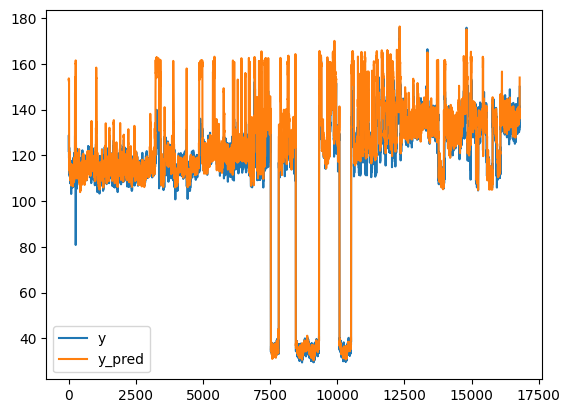

In [107]:
import matplotlib.pyplot as plt

t = 0
n = 240000
y_diff = y_preds - ys

mask = y_diff > 10

ys_filtered = ys[mask]
y_preds_filtered = y_preds[mask]
y_dates_filtered = (np.array(y_dates))[mask]
# plt.plot(all_ys[t:t+n], label="y")
# plt.plot(all_y_preds[t:t+n], label="y_pred")


# plt.plot(ys_filtered[t:t+n], label="y")
# plt.plot(y_preds_filtered[t:t+n], label="y_pred")

plt.plot(ys[t:t + n], label="y")
plt.plot(y_preds[t:t + n], label="y_pred")

# plt.plot(y_preds[t:t+n] - ys[t:t+n], label="y_diff")

plt.legend()
plt.show()

In [109]:
my_func = lambda x: x[0] + "_" + x[1]
result = np.apply_along_axis(my_func, axis=1, arr=y_dates_filtered)
a, b = np.unique(result, return_counts=True)

In [110]:
a[b > 100], b[b > 100]

(array(['جنوب اصف', 'سبلان_G1', 'سیکل ترک', 'شهدای پی', 'عسلویه_G'],
       dtype='<U8'),
 array([286, 120, 819, 235, 298]))

In [111]:
a[b < 100], b[b < 100]

(array(['حافظ_G11', 'حافظ_G12', 'حافظ_G13', 'حافظ_G15', 'حافظ_G16',
        'سبلان_S1', 'عسلویه_S', 'پرند_G11', 'پرند_G12', 'پرند_G13',
        'پرند_G14', 'پرند_G15', 'پرند_G16'], dtype='<U8'),
 array([24, 51, 44, 26, 18, 20, 20, 34, 19, 41, 19, 18, 13]))

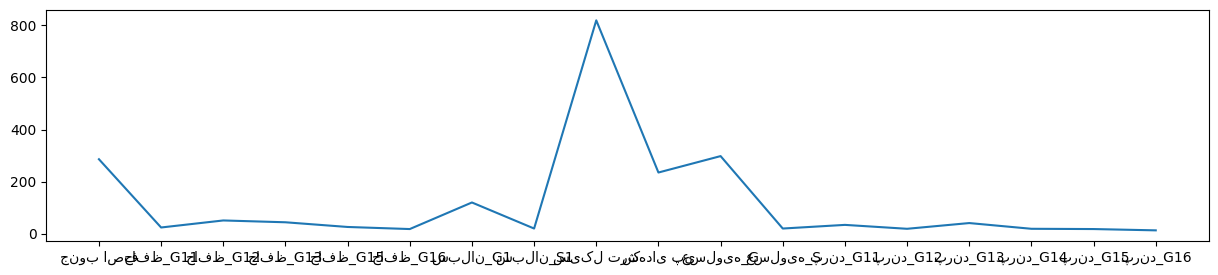

In [112]:
plt.figure(figsize=(15, 3))
_ = plt.plot(a, b)

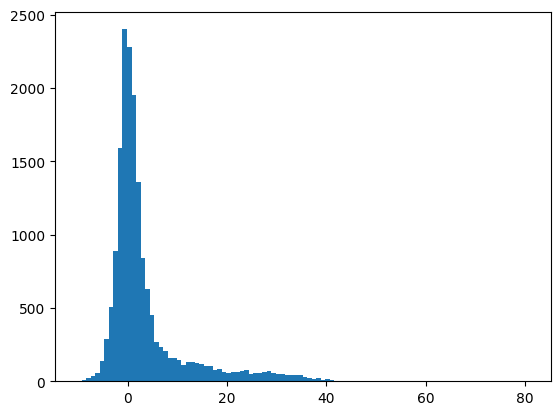

In [38]:

plt.hist(y_diff, bins=100)
plt.show()